### Core functions

In [4]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import src.estimators as estimators
import src.dataset_generator as dataset_generator
import src.auxiliar as aux
import src.entropy_estimator as entropy_estimator

In [5]:
def compute_classificability_analytically(x, raws, ps, rhos, colors=None):
    with np.errstate(divide='ignore', invalid='ignore'):
        classificability = 1 - np.sum([entropy_estimator.entropy(x, p, rho) for p, rho in zip(ps, rhos)])
        aux.print_classificability(classificability)
        aux.theoretical_plots(x, raws, ps, rhos, colors=colors)
    return classificability

def compute_classificability_numerically(x, raws, sample_points=10000, colors=None, force_balance=True, pdf_resolution=10000):
    # Compute classificability numerically (Optimal model is a simple threshold).
    domain = [np.min(x), np.max(x)]
    x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, sample_points, resolution=pdf_resolution, force_balance=force_balance)
    optimal_threshold, max_accuracy = estimators.one_dim_two_class_threshold_estimator(x_data, y_data, domain, resolution=100)
    aux.print_numerical_classificability(max_accuracy)
    aux.data_plots(x_data, y_data, optimal_threshold, raws, domain, raws=None, colors=colors, bins=30)
    return max_accuracy

def estimate_classificability_numerically(x, raws, analytical_classificability, numerical_classificability, estimation_measurement_threshold = 0.025, sample_points=2500, colors=None, force_balance=True, pdf_resolution=10000):
    # Estimate classificability numerically (Entropy around points).
    domain = [np.min(x), np.max(x)]
    distance_thresholds = np.linspace(0,0.2,25)
    classificabilities, probs, entropies, xs_data, ys_data = [], [], [], [], []
    measurement_classificabilities = []
    for i in range(3):
        with np.errstate(divide='ignore', invalid='ignore'):
            x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, sample_points, resolution=pdf_resolution, force_balance=force_balance)
            xs_data.append(x_data)
            ys_data.append(y_data)
            c, p, h = entropy_estimator.classificability_estimator(x_data, y_data, distance_threshold=estimation_measurement_threshold, return_probs=True, return_entropies=True)
            measurement_classificabilities.append([estimation_measurement_threshold, c])
            probs.append(p)
            entropies.append(h)
            cs = []
            for th in distance_thresholds:
                c = entropy_estimator.classificability_estimator(x_data, y_data, distance_threshold=th)
                cs.append(c)
            classificabilities.append(cs)
    cs = np.array(measurement_classificabilities)[:,1]
    aux.print_sampling_classificability(np.mean(cs), np.std(cs, ddof=1))
    aux.estimation_plots(classificabilities, analytical_classificability, numerical_classificability, measurement_classificabilities, probs, entropies, xs_data, ys_data, distance_thresholds, domain, colors=colors, bins=30)

### Example 1.a : Constants


				####################################################################
							Classificability: 0.5000
				####################################################################



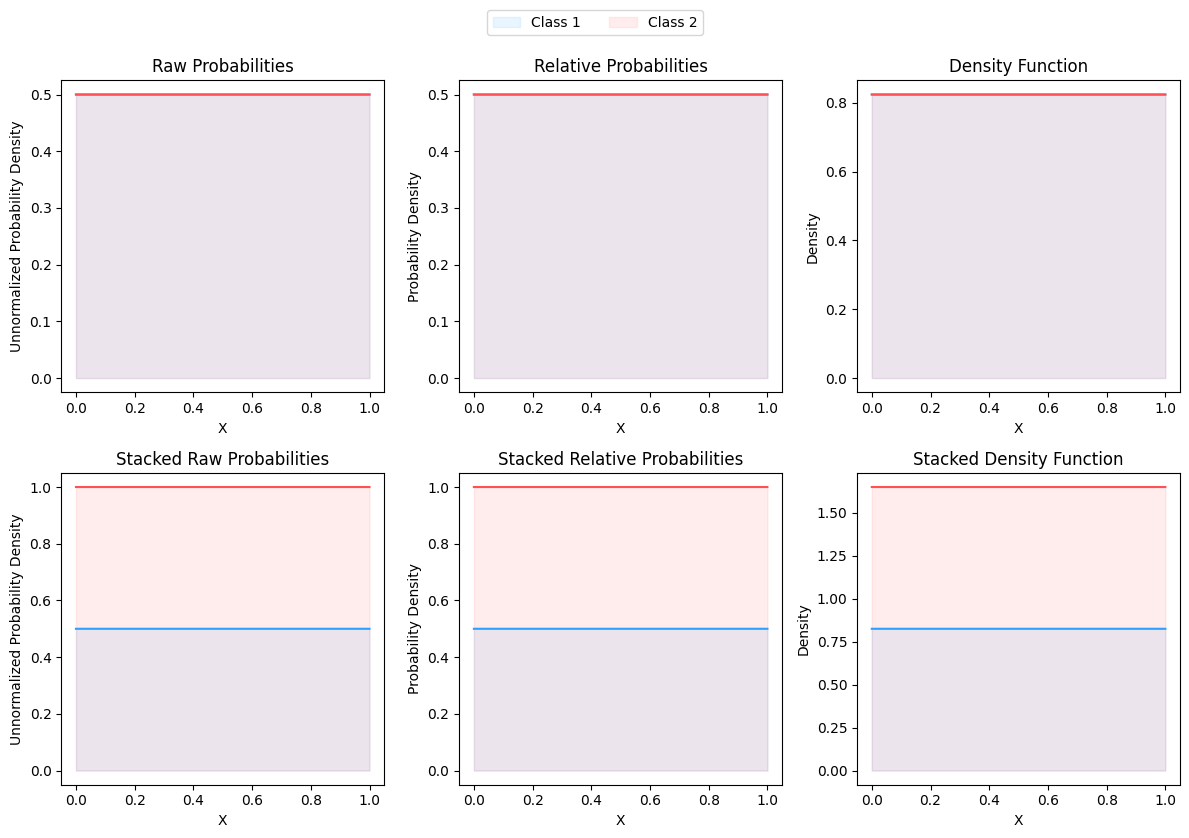


				####################################################################
						  Numerical Classificability: 0.5062
				####################################################################



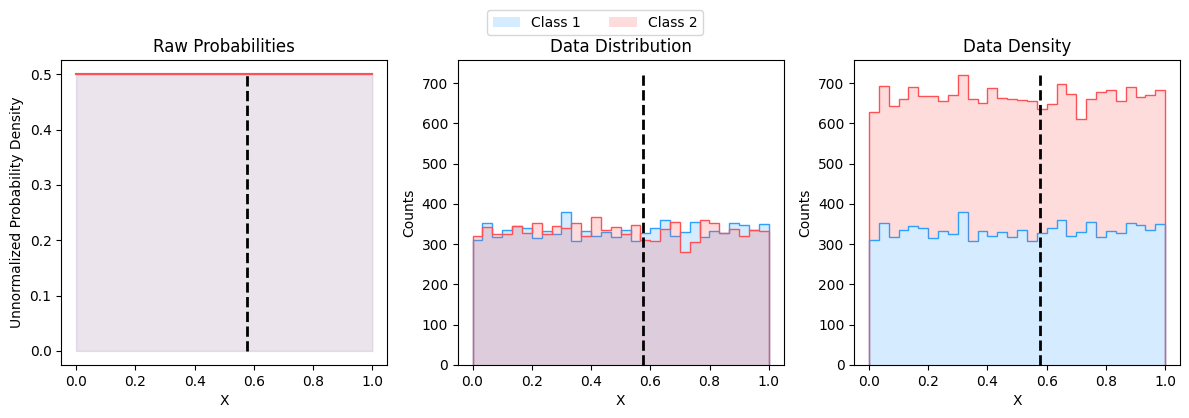


				####################################################################
					      Estimated Classificability: 0.5226 ± 0.0008
				####################################################################



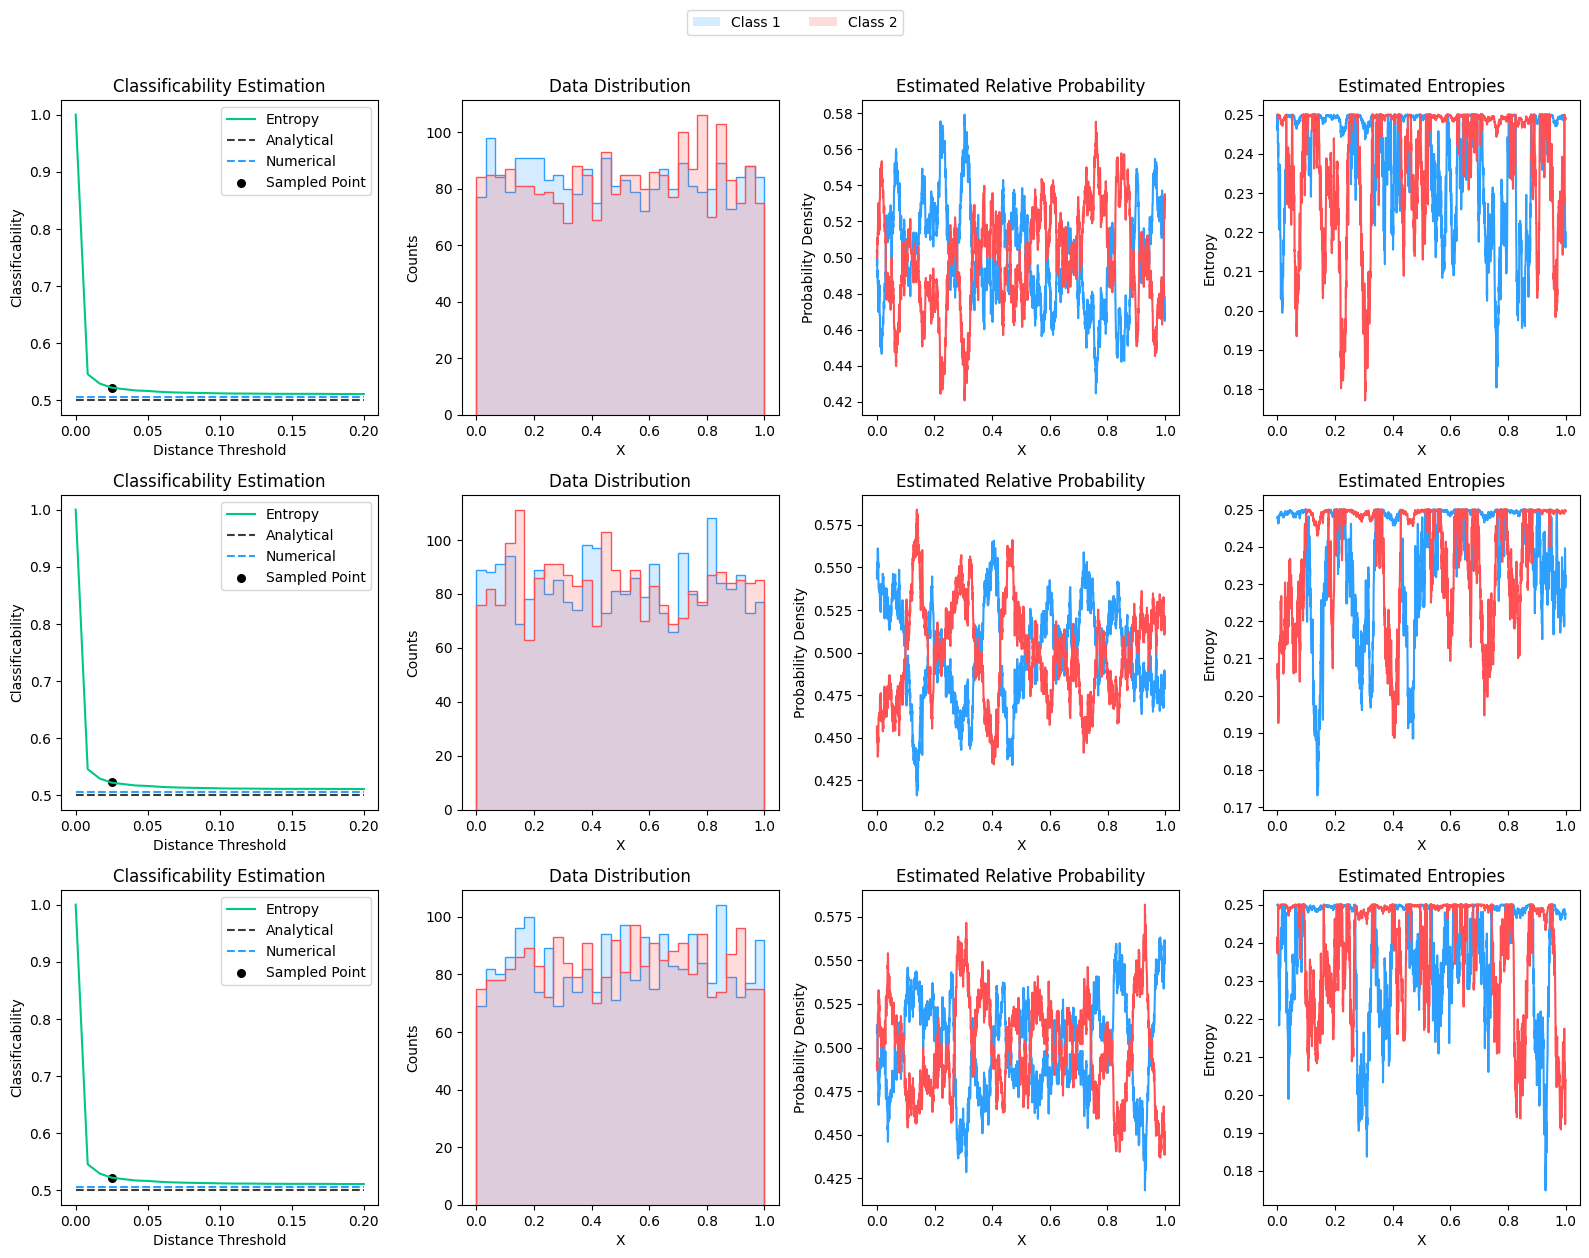

In [6]:
# Compute classificability analytically.
x = np.arange(0,1,0.0001)
raw_1 = lambda x : 1/2 * np.ones_like(x)
raw_2 = lambda x : 1/2 * np.ones_like(x)

p_1 = lambda x : raw_1(x) / (raw_1(x) + raw_2(x)) 
rho_1 = lambda x : (1/2)*(np.e)**(1/2) * np.ones_like(x)

p_2 = lambda x : raw_2(x) / (raw_1(x) + raw_2(x)) 
rho_2 = lambda x : (1/2)*(np.e)**(1/2) * np.ones_like(x)

raws = [raw_1, raw_2]
ps = [p_1, p_2]
rhos = [rho_1, rho_2]
colors = ['#2D9FFF', '#FF5154']
force_balance = True

analytical_classificability = compute_classificability_analytically(x, raws, ps, rhos, colors=colors)
numerical_classificability = compute_classificability_numerically(x, raws, sample_points=10000, colors=colors, force_balance=force_balance)
estimate_classificability_numerically(x, raws, analytical_classificability, numerical_classificability, estimation_measurement_threshold=0.025, sample_points=2500, colors=colors, force_balance=force_balance)

### Examples 1.b : Imbalanced Constants


				####################################################################
							Classificability: 0.6667
				####################################################################



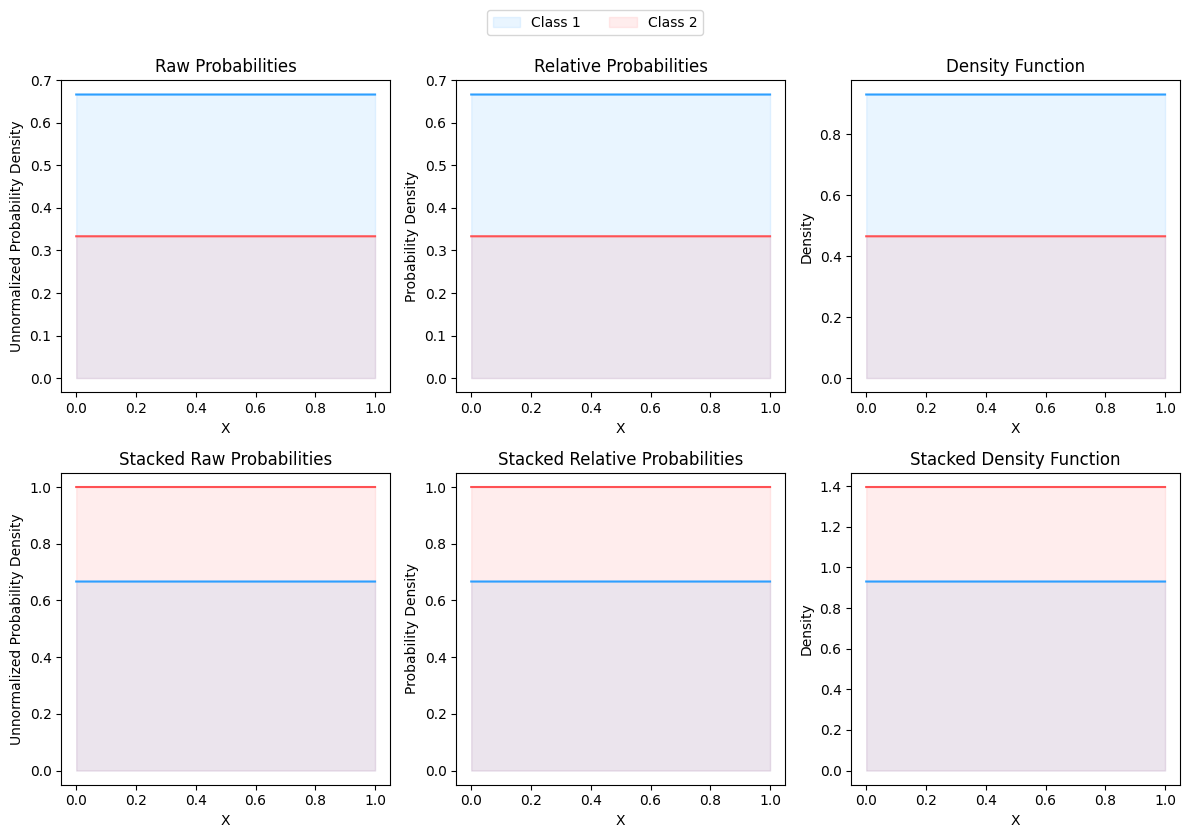


				####################################################################
						  Numerical Classificability: 0.6668
				####################################################################



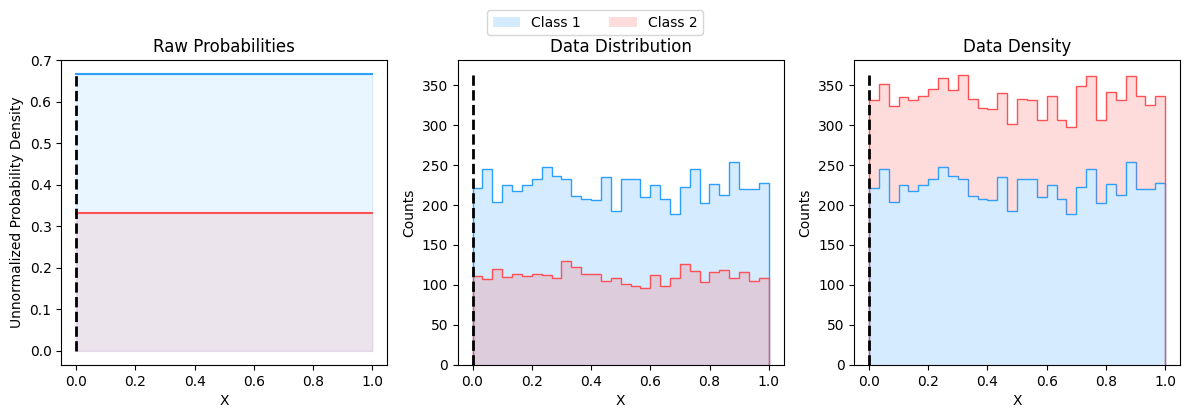


				####################################################################
					      Estimated Classificability: 0.6663 ± 0.0004
				####################################################################



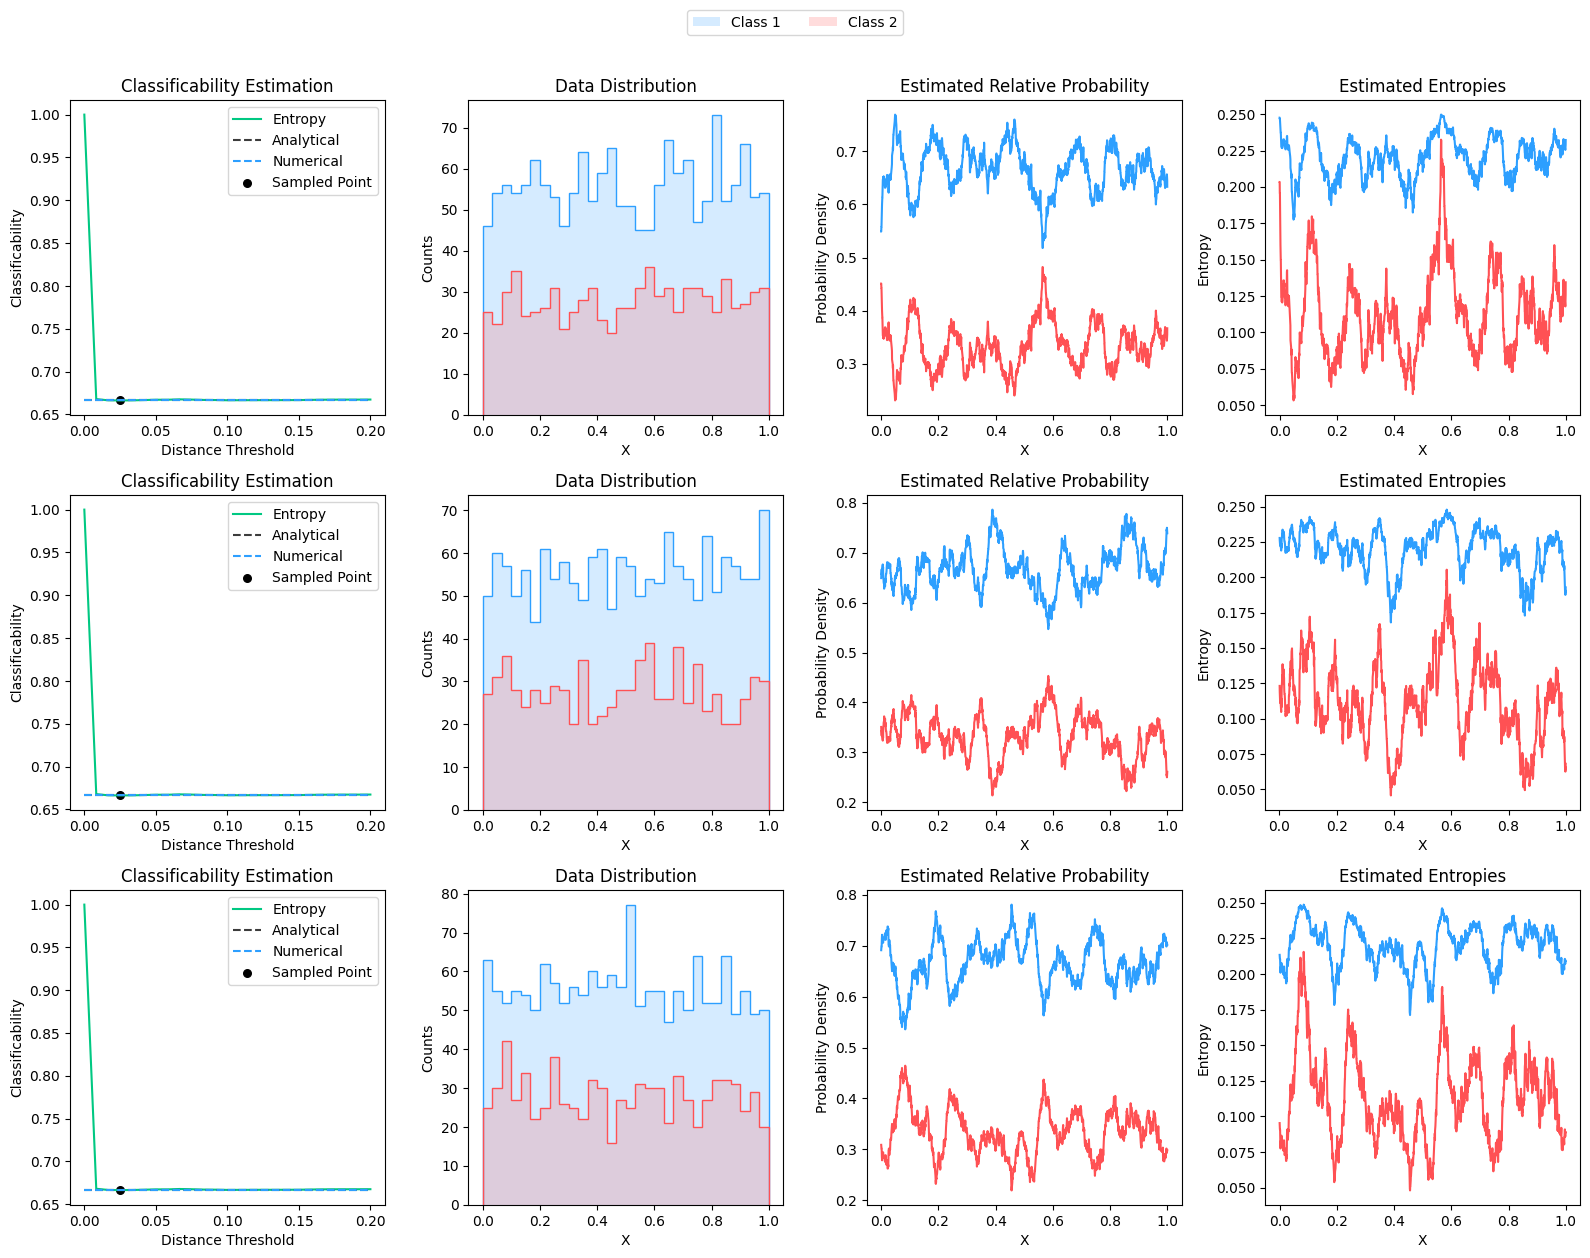

In [7]:
x = np.arange(0,1,0.0001)
raw_1 = lambda x : 2/3 * np.ones_like(x)
raw_2 = lambda x : 1/3 * np.ones_like(x)

p_1 = lambda x : raw_1(x) / (raw_1(x) + raw_2(x)) 
rho_1 = lambda x : (2/3)*(np.e)**(1/3) * np.ones_like(x)

p_2 = lambda x : raw_2(x) / (raw_1(x) + raw_2(x)) 
rho_2 = lambda x : (1/3)*(np.e)**(1/3) * np.ones_like(x)

raws = [raw_1, raw_2]
ps = [p_1, p_2]
rhos = [rho_1, rho_2]
colors = ['#2D9FFF', '#FF5154']
force_balance = False

analytical_classificability = compute_classificability_analytically(x, raws, ps, rhos, colors=colors)
numerical_classificability = compute_classificability_numerically(x, raws, sample_points=10000, colors=colors, force_balance=force_balance)
estimate_classificability_numerically(x, raws, analytical_classificability, numerical_classificability, estimation_measurement_threshold=0.025, sample_points=2500, colors=colors, force_balance=force_balance)

### Examples 1.c : Imbalanced Constants


				####################################################################
							Classificability: 0.9000
				####################################################################



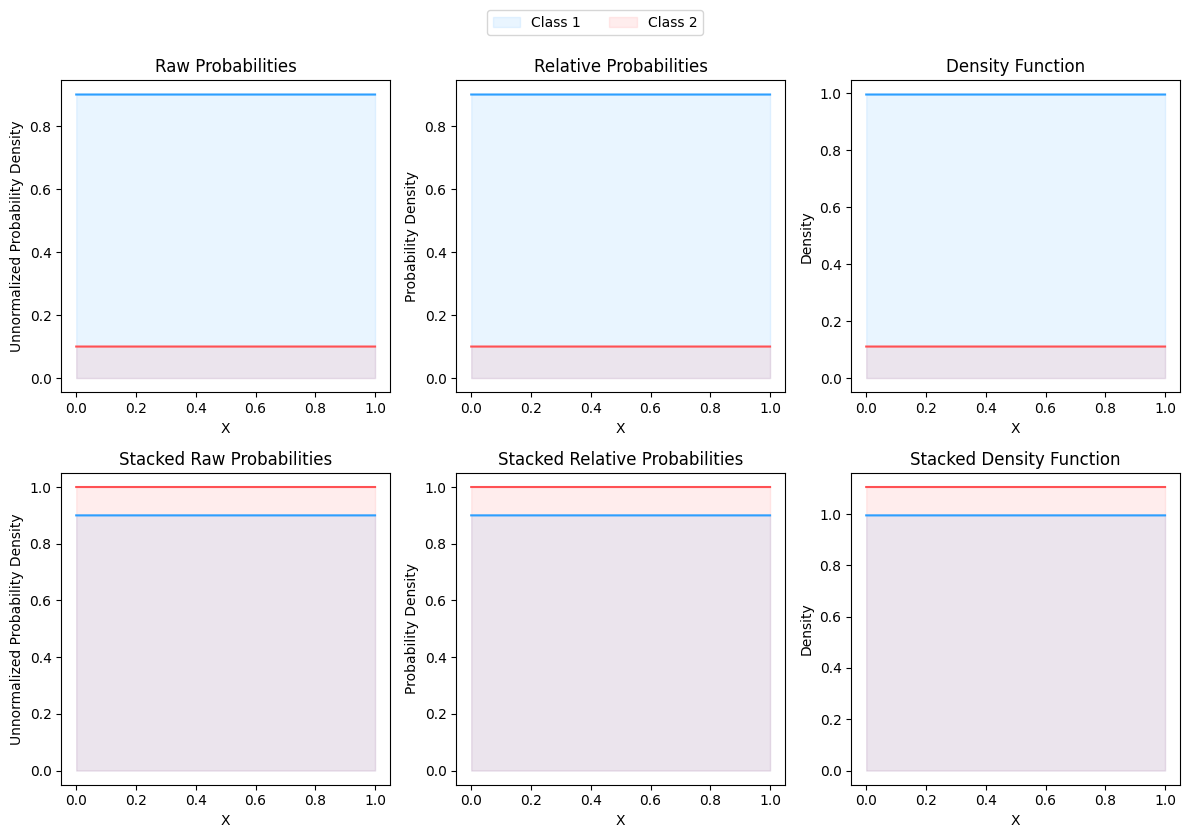


				####################################################################
						  Numerical Classificability: 0.9001
				####################################################################



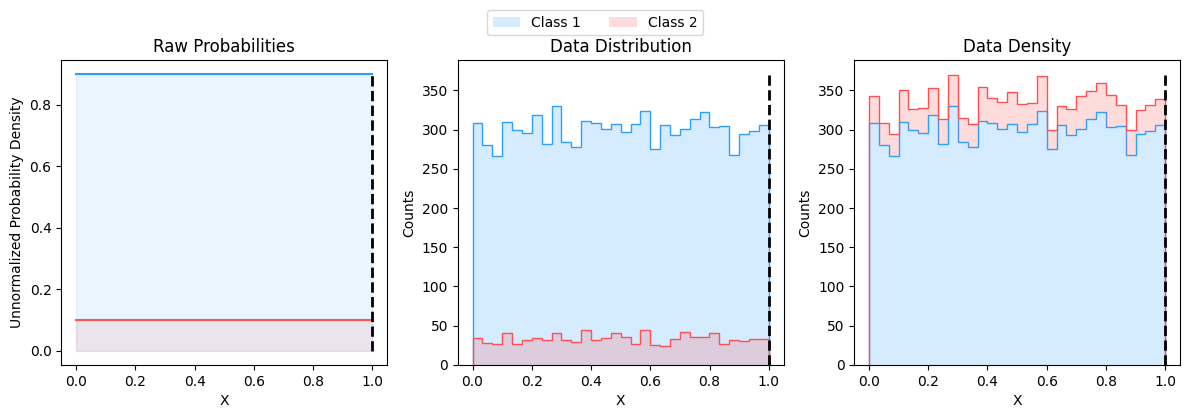


				####################################################################
					      Estimated Classificability: 0.9004 ± 0.0005
				####################################################################



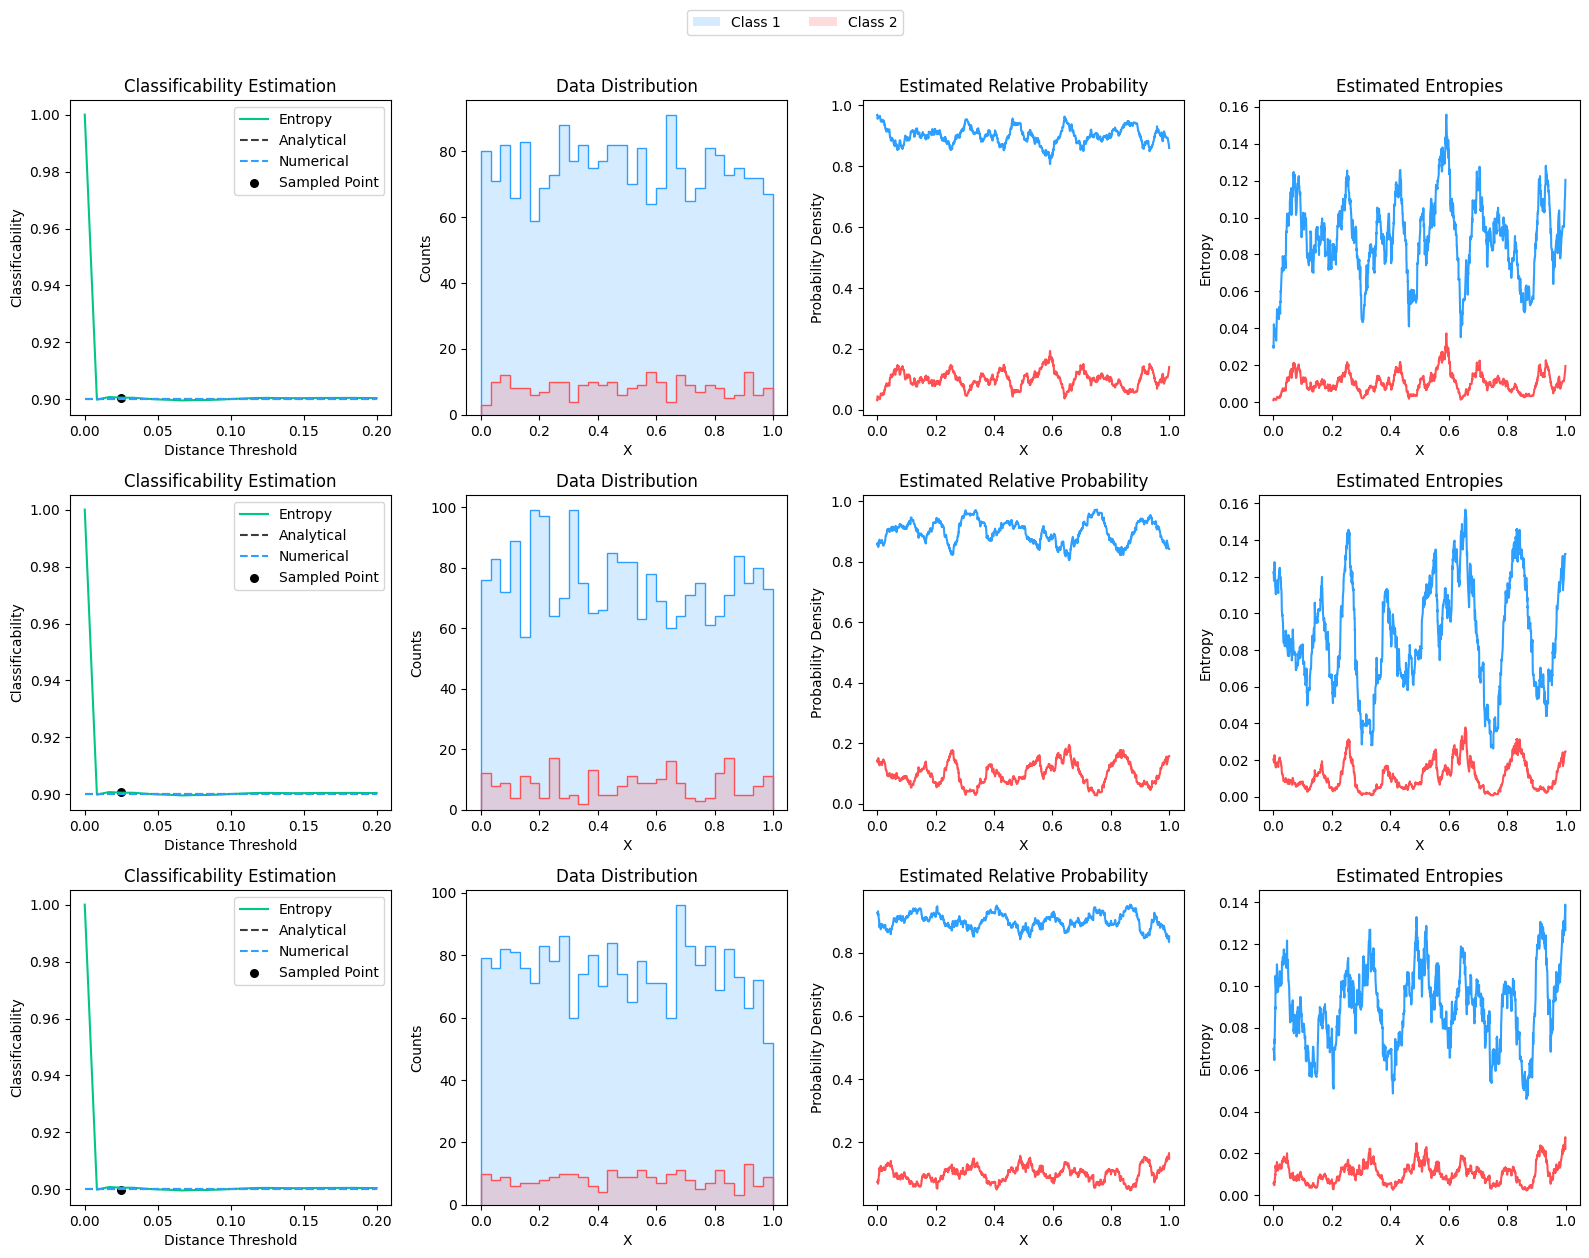

In [8]:
x = np.arange(0,1,0.0001)
raw_1 = lambda x : 9/10 * np.ones_like(x)
raw_2 = lambda x : 1/10 * np.ones_like(x)

p_1 = lambda x : raw_1(x) / (raw_1(x) + raw_2(x)) 
rho_1 = lambda x : (9/10)*(np.e)**(1/10) * np.ones_like(x)

p_2 = lambda x : raw_2(x) / (raw_1(x) + raw_2(x)) 
rho_2 = lambda x : (1/10)*(np.e)**(1/10) * np.ones_like(x)

raws = [raw_1, raw_2]
ps = [p_1, p_2]
rhos = [rho_1, rho_2]
colors = ['#2D9FFF', '#FF5154']
force_balance = False

analytical_classificability = compute_classificability_analytically(x, raws, ps, rhos, colors=colors)
numerical_classificability = compute_classificability_numerically(x, raws, sample_points=10000, colors=colors, force_balance=force_balance)
estimate_classificability_numerically(x, raws, analytical_classificability, numerical_classificability, estimation_measurement_threshold=0.025, sample_points=2500, colors=colors, force_balance=force_balance)

### Example 3: Two Rectangle Triangles


				####################################################################
							Classificability: 0.7500
				####################################################################



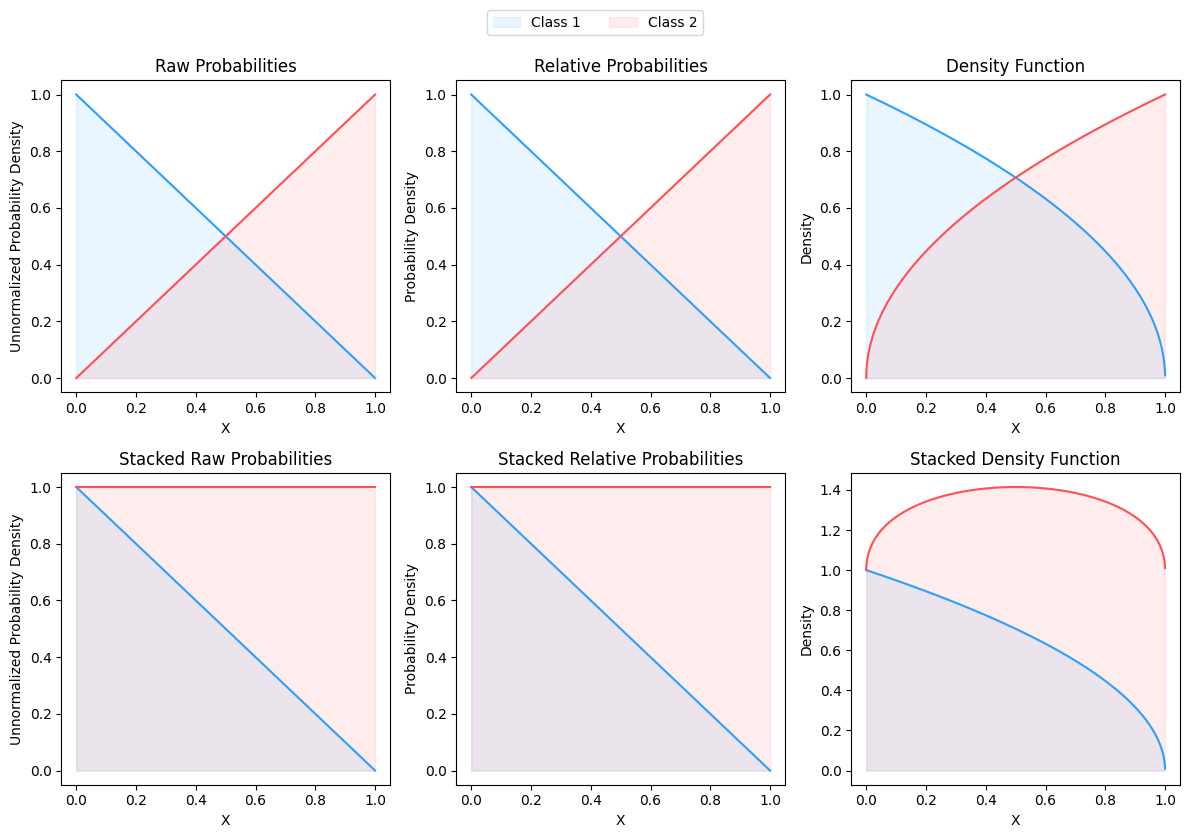


				####################################################################
						  Numerical Classificability: 0.7510
				####################################################################



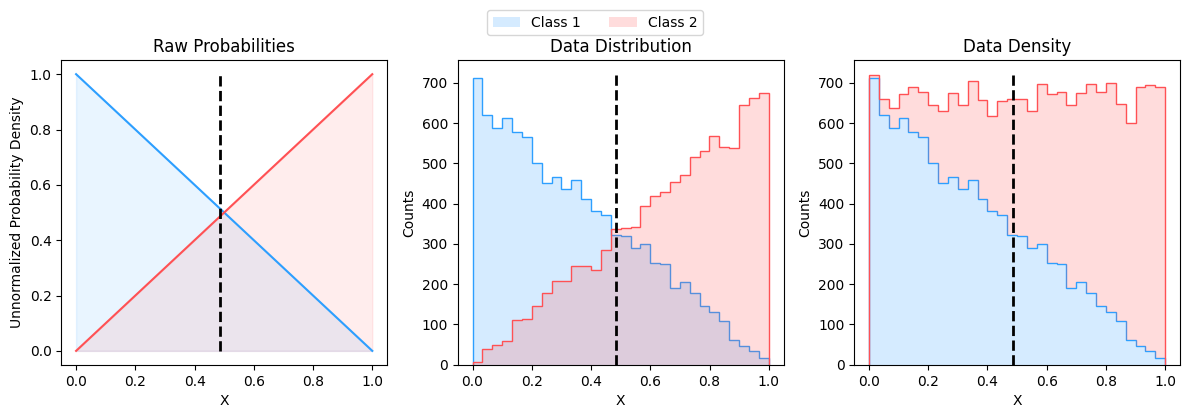


				####################################################################
					      Estimated Classificability: 0.7547 ± 0.0105
				####################################################################



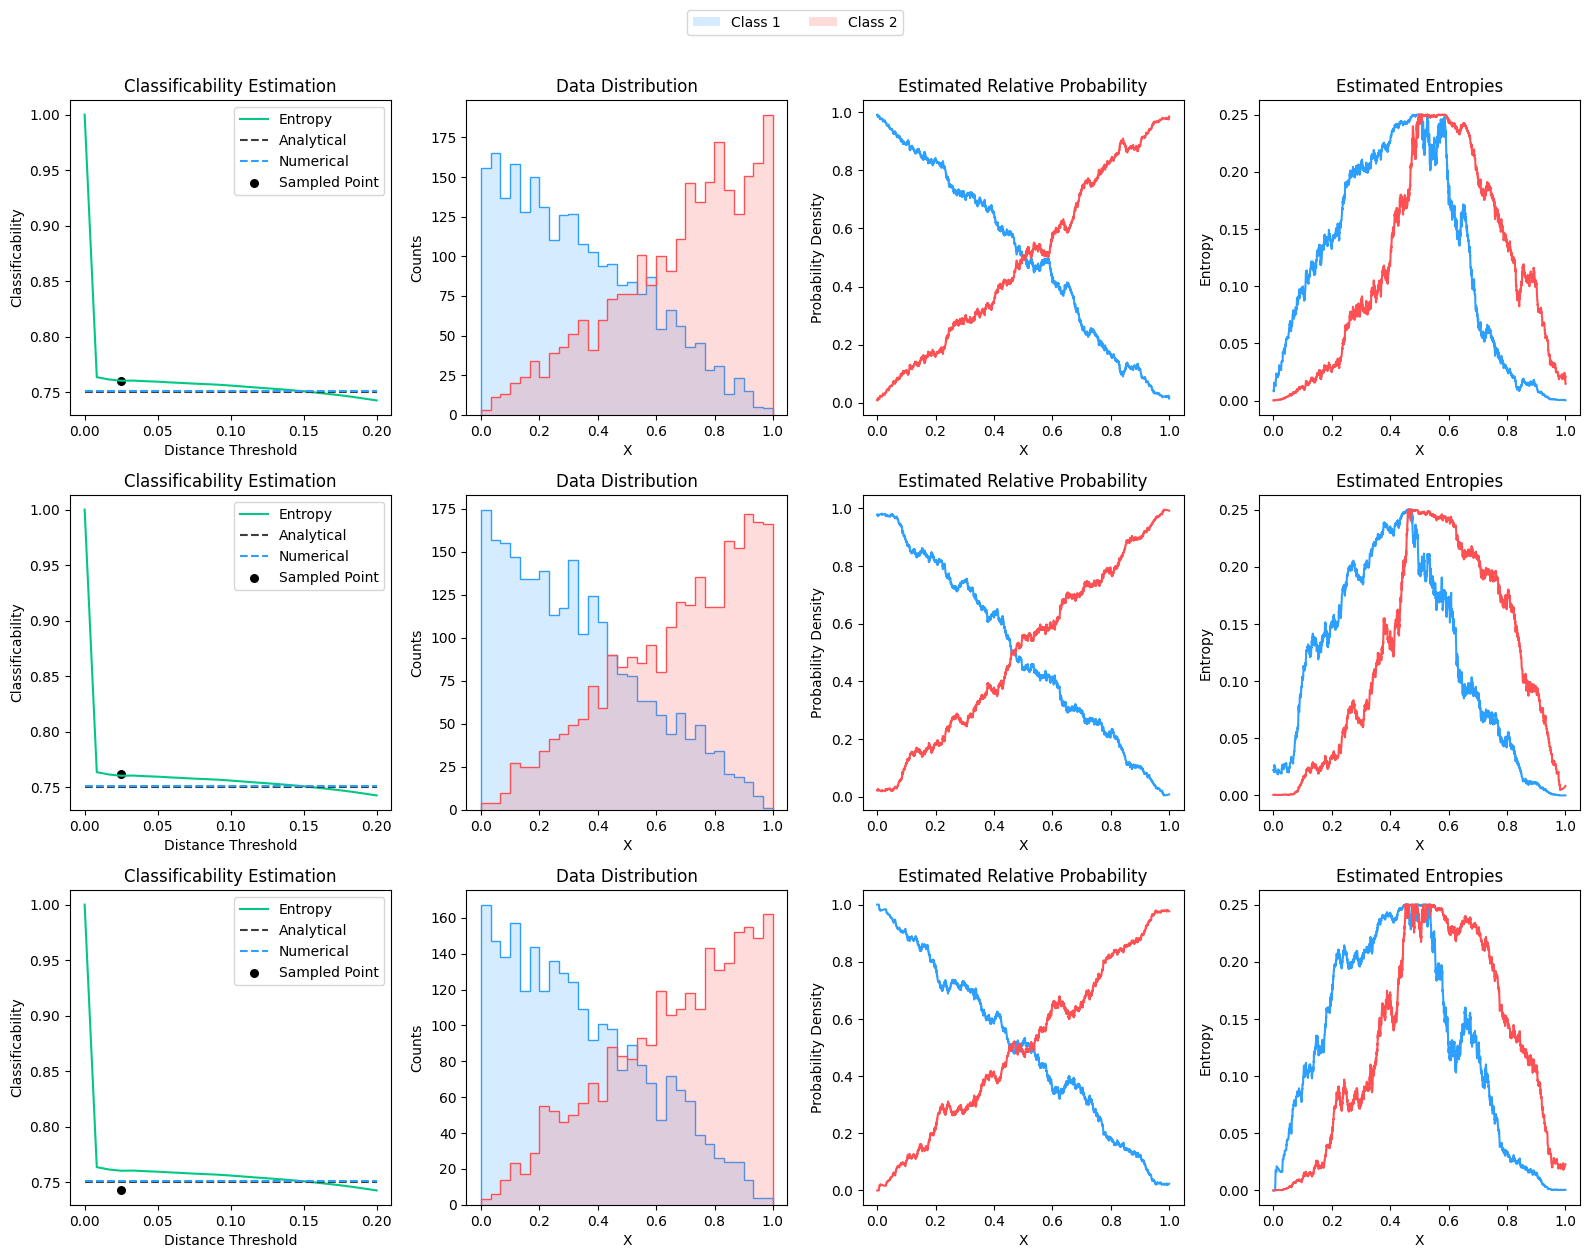

In [9]:
x = np.arange(0,1,0.0001)
raw_1 = lambda x : 1 - x
raw_2 = lambda x : x

p_1 = lambda x : raw_1(x) / (raw_1(x) + raw_2(x)) 
rho_1 = lambda x : (1 - x)**(1/2)

p_2 = lambda x : raw_2(x) / (raw_1(x) + raw_2(x)) 
rho_2 = lambda x : x**(1/2)

raws = [raw_1, raw_2]
ps = [p_1, p_2]
rhos = [rho_1, rho_2]
colors = ['#2D9FFF', '#FF5154']
force_balance = True

analytical_classificability = compute_classificability_analytically(x, raws, ps, rhos, colors=colors)
numerical_classificability = compute_classificability_numerically(x, raws, sample_points=10000, colors=colors, force_balance=force_balance)
estimate_classificability_numerically(x, raws, analytical_classificability, numerical_classificability, estimation_measurement_threshold=0.025, sample_points=2500, colors=colors, force_balance=force_balance)

### Example 4: Two Imbalanced Rectangle Triangles


				####################################################################
							Classificability: 0.7598
				####################################################################



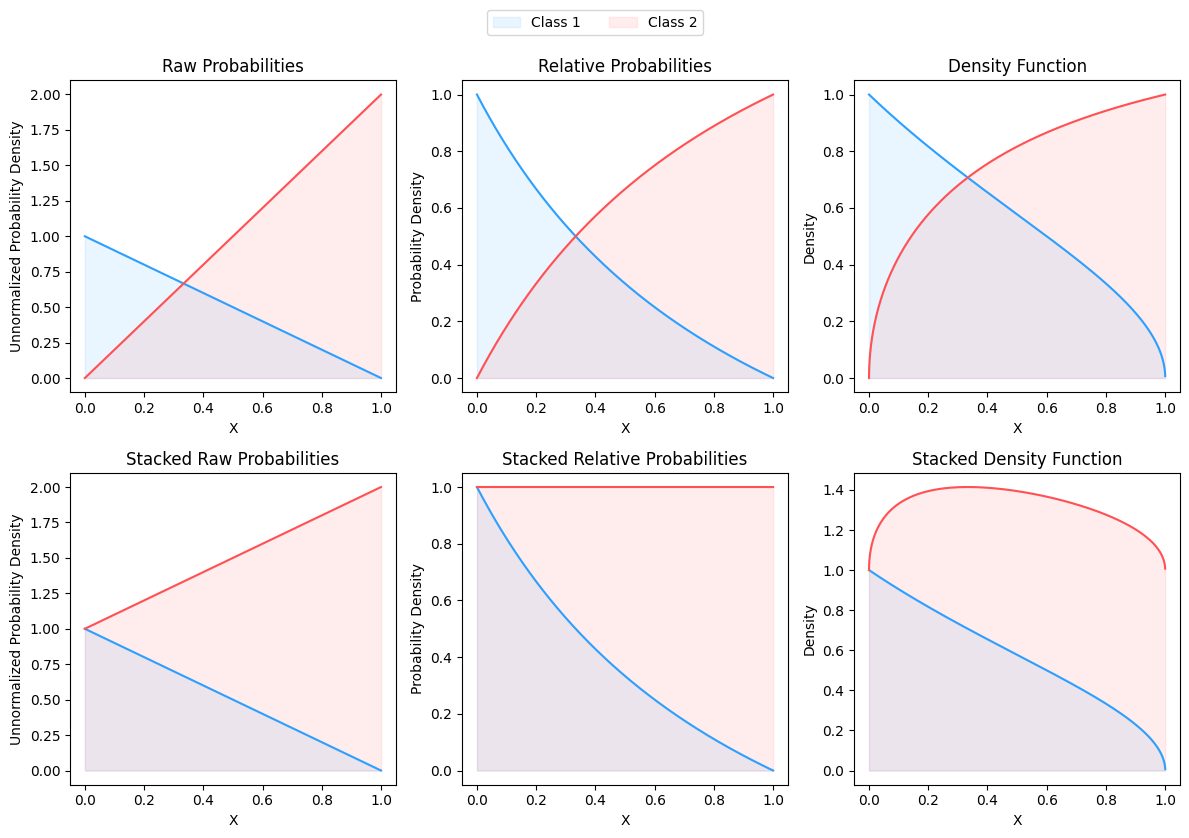


				####################################################################
						  Numerical Classificability: 0.7800
				####################################################################



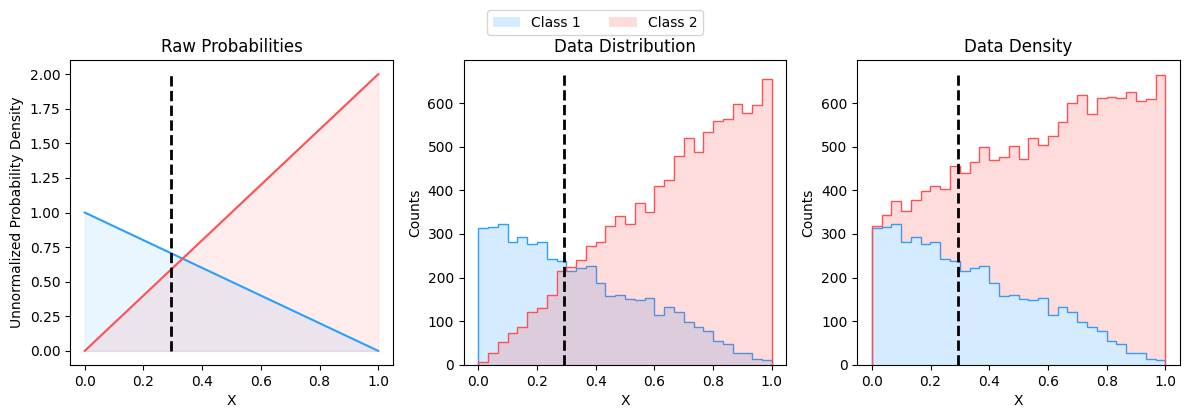


				####################################################################
					      Estimated Classificability: 0.7849 ± 0.0056
				####################################################################



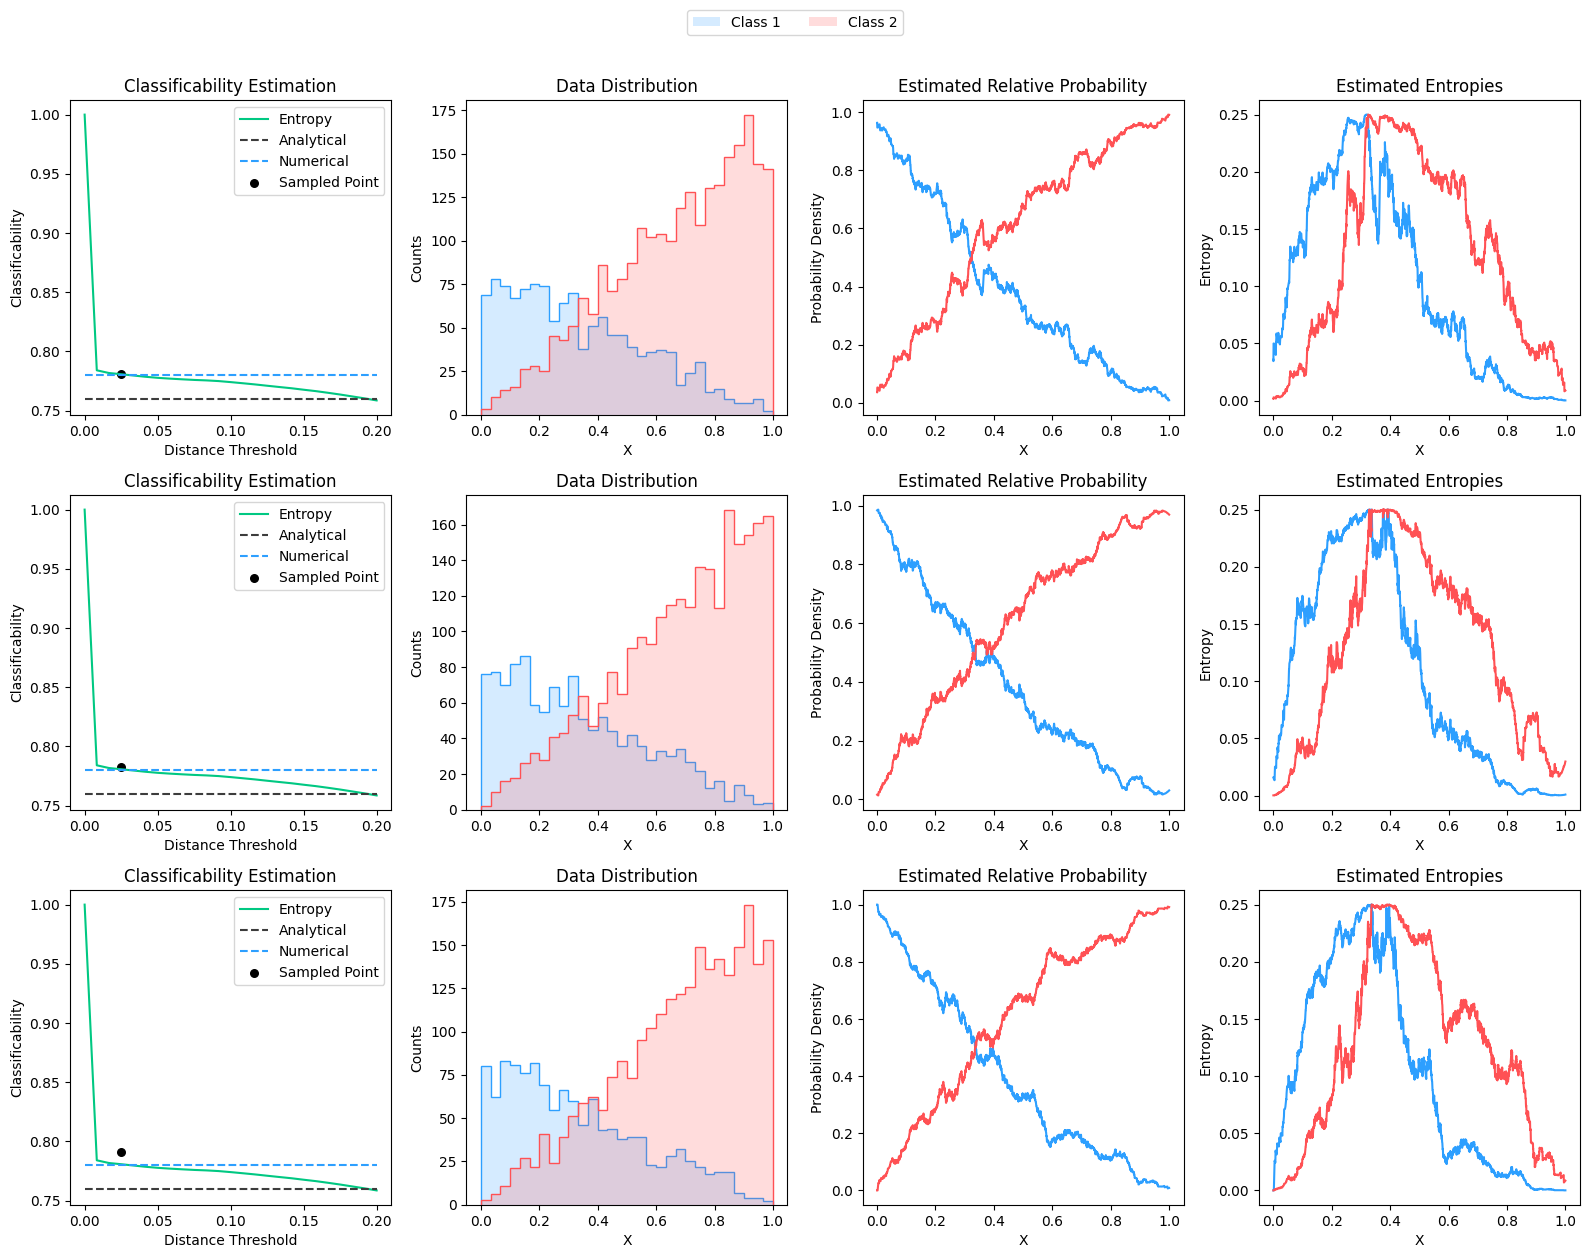

In [10]:
x = np.arange(0,1,0.0001)
raw_1 = lambda x : 1 - x
raw_2 = lambda x : 2*x

p_1 = lambda x : raw_1(x) / (raw_1(x) + raw_2(x)) 
rho_1 = lambda x : (p_1(x))**(1/2)

p_2 = lambda x : raw_2(x) / (raw_1(x) + raw_2(x)) 
rho_2 = lambda x : (p_2(x))**(1/2)

raws = [raw_1, raw_2]
ps = [p_1, p_2]
rhos = [rho_1, rho_2]
colors = ['#2D9FFF', '#FF5154']
force_balance = False

analytical_classificability = compute_classificability_analytically(x, raws, ps, rhos, colors=colors)
numerical_classificability = compute_classificability_numerically(x, raws, sample_points=10000, colors=colors, force_balance=force_balance)
estimate_classificability_numerically(x, raws, analytical_classificability, numerical_classificability, estimation_measurement_threshold=0.025, sample_points=2500, colors=colors, force_balance=force_balance)

### Example 5: One Rectangle Triangle and one Isoceles Triangle


				####################################################################
							Classificability: 0.6892
				####################################################################



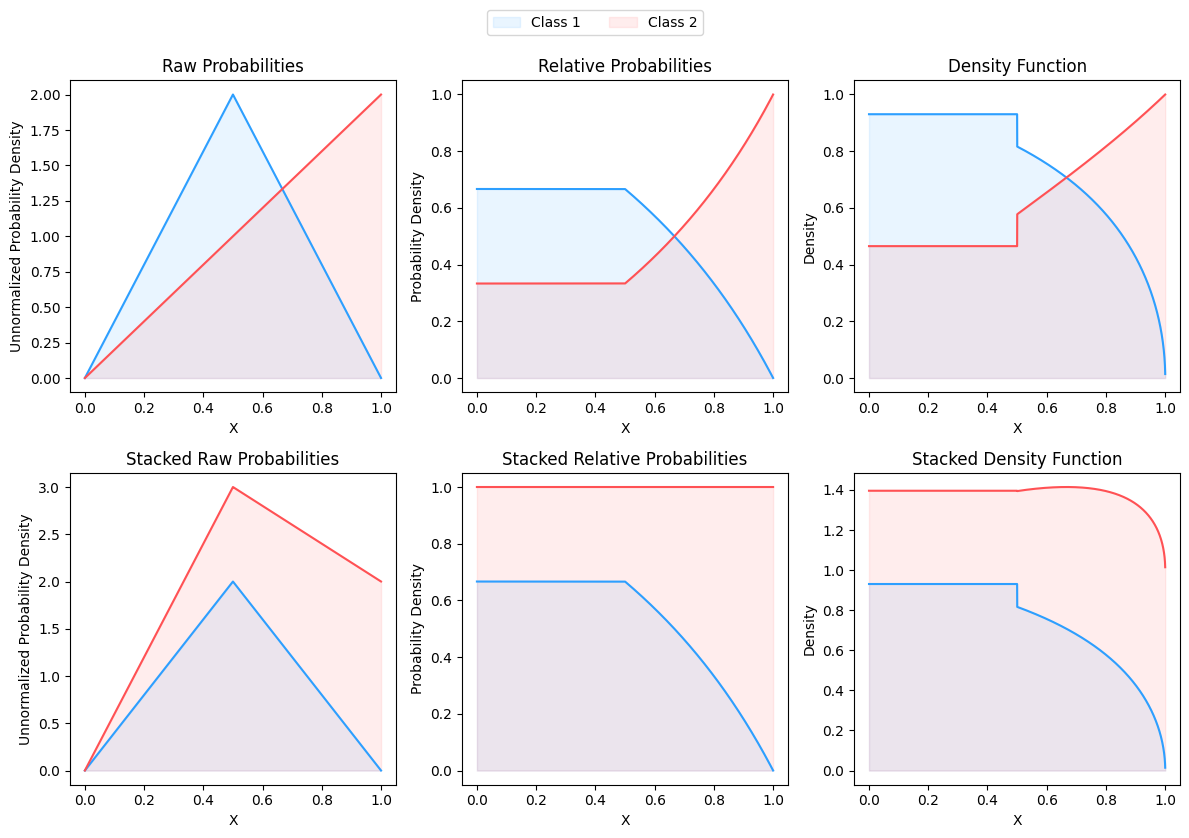


				####################################################################
						  Numerical Classificability: 0.6634
				####################################################################



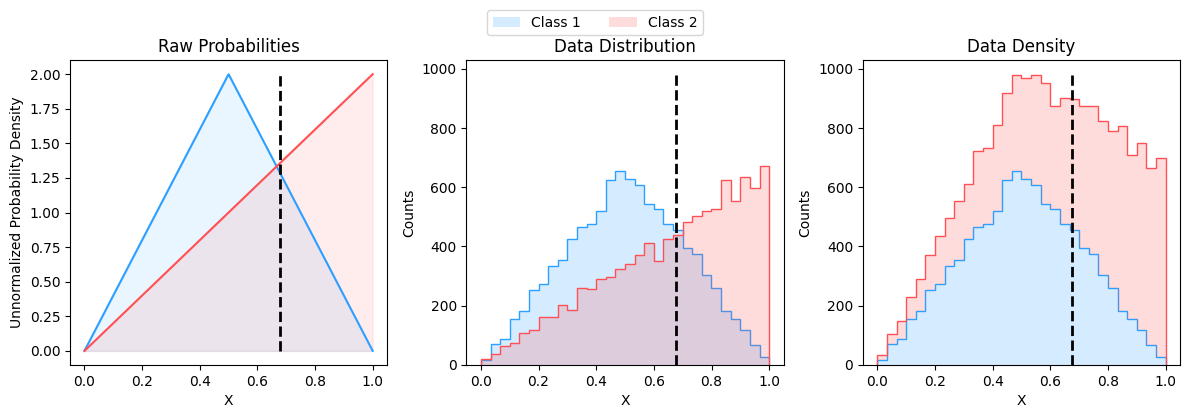


				####################################################################
					      Estimated Classificability: 0.6636 ± 0.0009
				####################################################################



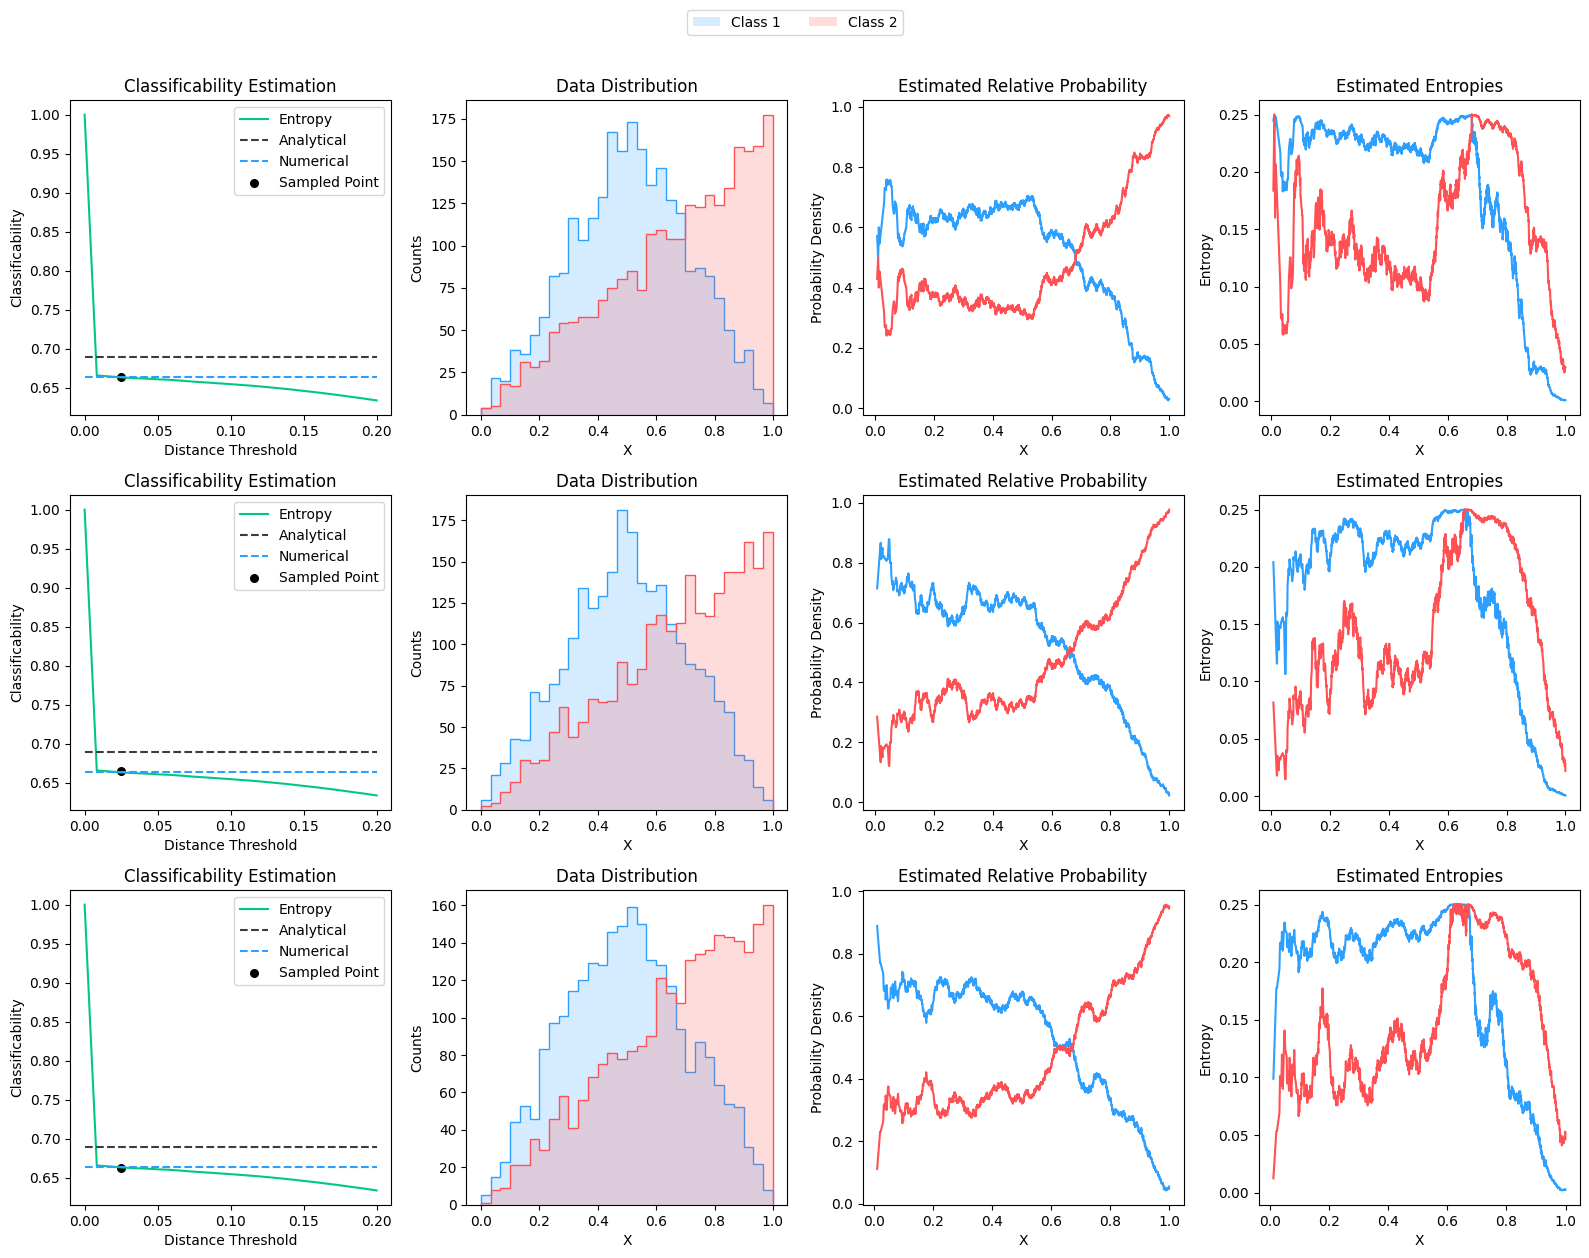

In [11]:
x = np.arange(0,1,0.0001)
raw_1 = lambda x : np.where(x > 0.5, 4*(1-x), 4*x)
raw_2 = lambda x : 2*x

p_1 = lambda x : raw_1(x) / (raw_1(x) + raw_2(x)) 
rho_1 = lambda x : np.where(x > 0.5, ((1 - x)/(1 - 0.5*x))**(1/2), 2/3 * np.e**(1/3))

p_2 = lambda x : raw_2(x) / (raw_1(x) + raw_2(x)) 
rho_2 = lambda x : np.where(x > 0.5, (x/(2-x))**(1/2), 1/3 * np.e**(1/3))

raws = [raw_1, raw_2]
ps = [p_1, p_2]
rhos = [rho_1, rho_2]
colors = ['#2D9FFF', '#FF5154']
force_balance = True

analytical_classificability = compute_classificability_analytically(x, raws, ps, rhos, colors=colors)
numerical_classificability = compute_classificability_numerically(x, raws, sample_points=10000, colors=colors, force_balance=force_balance)
estimate_classificability_numerically(x, raws, analytical_classificability, numerical_classificability, estimation_measurement_threshold=0.025, sample_points=2500, colors=colors, force_balance=force_balance)

### Example 6: Two Gaussian Distributions


				####################################################################
							Classificability: 0.8413
				####################################################################



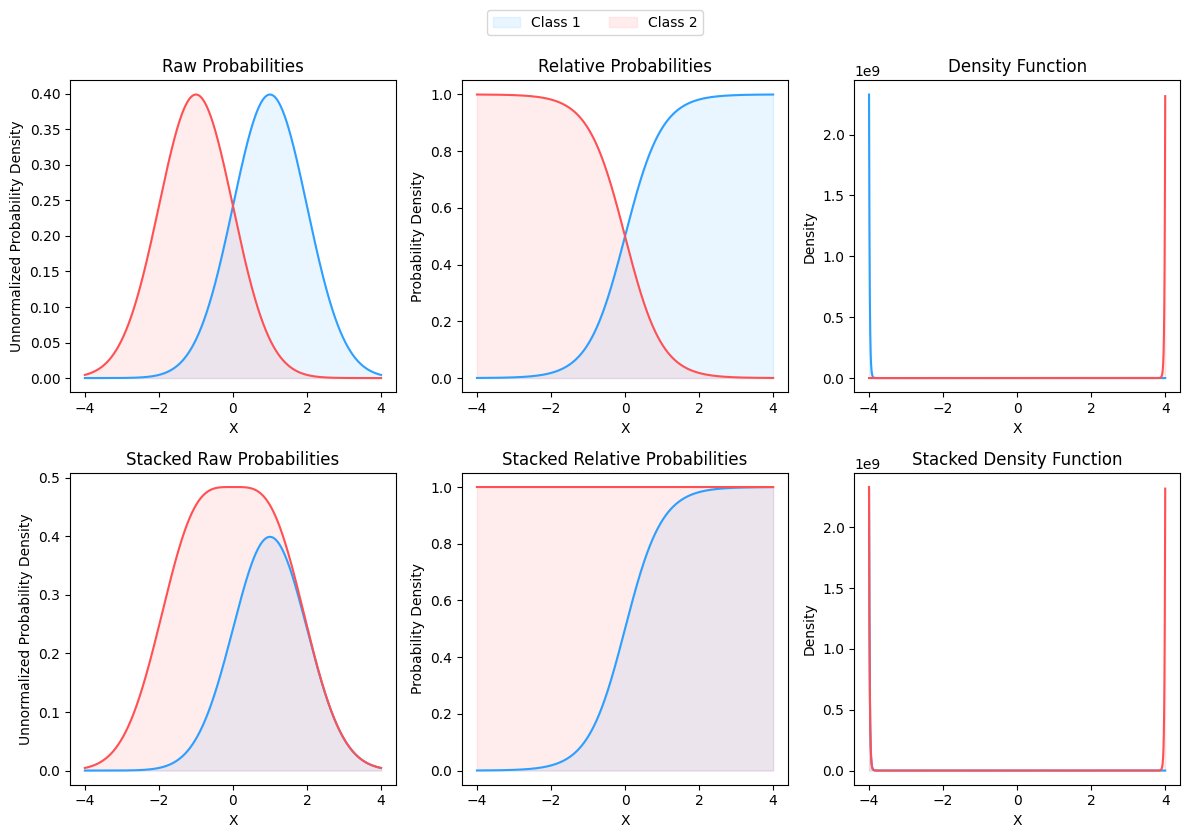


				####################################################################
						  Numerical Classificability: 0.8373
				####################################################################



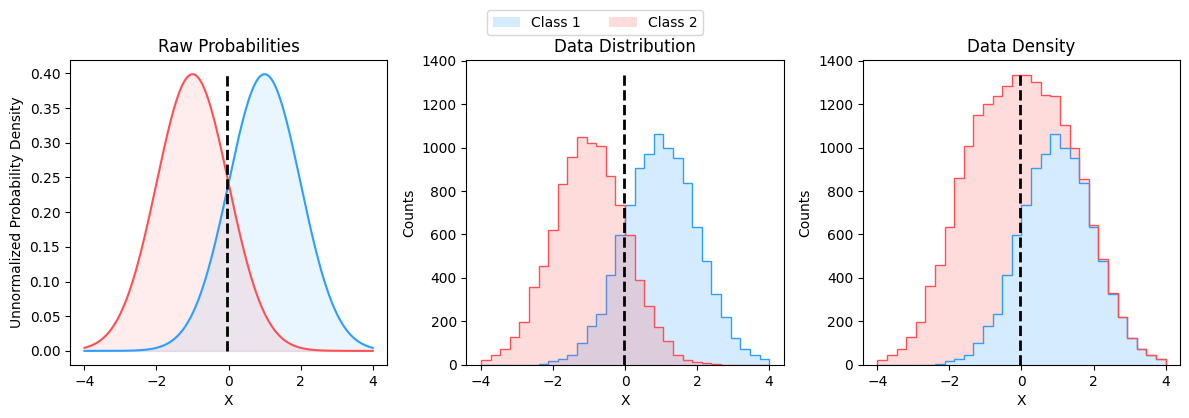


				####################################################################
					      Estimated Classificability: 0.8447 ± 0.0059
				####################################################################



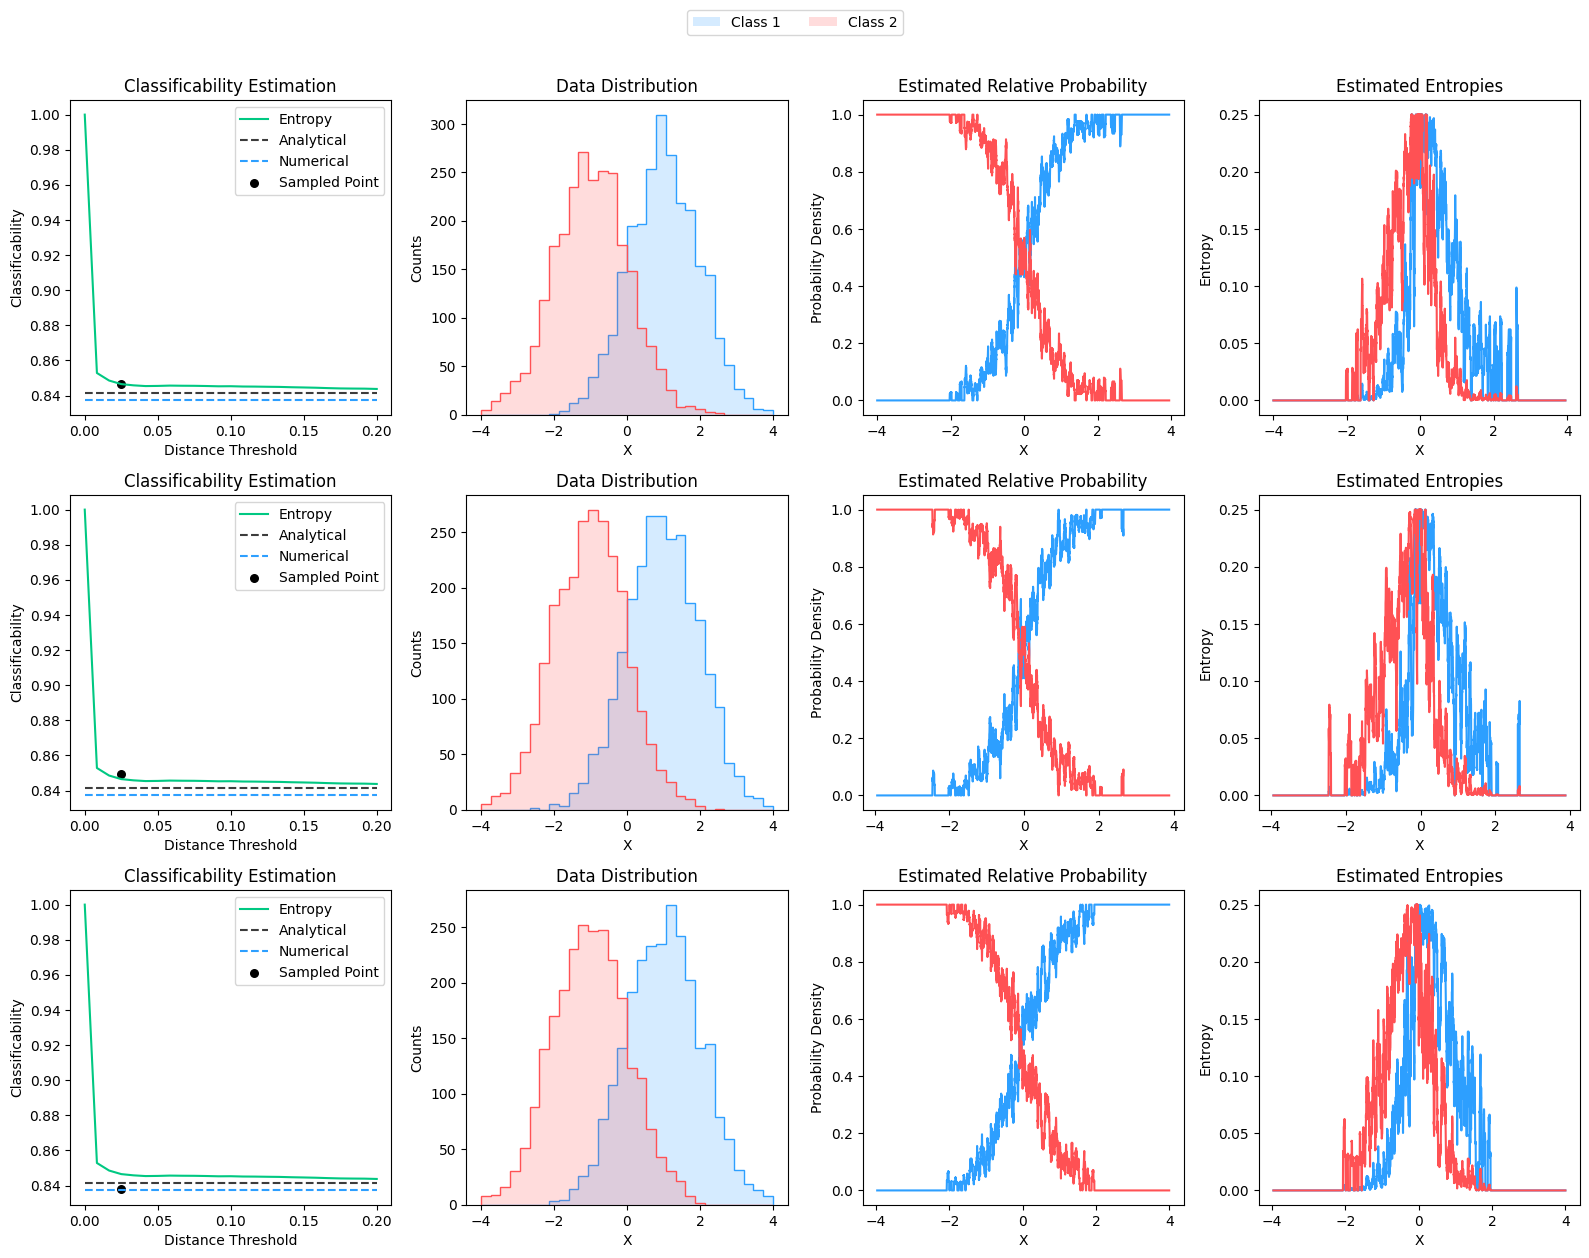

In [12]:
x = np.arange(-4,4,0.0001)
area = x[-1] - x[0]

raw_1 = lambda x : (1/np.sqrt(2*np.pi)) * np.exp( -0.5*(x - 1)**2 )
raw_2 = lambda x : (1/np.sqrt(2*np.pi)) * np.exp( -0.5*(x + 1)**2 )

p_1 = lambda x : raw_1(x) / (raw_1(x) + raw_2(x)) 
rho_1 = lambda x : np.where(p_1(x) > 0, p_1(x) * np.exp( 0.25 * ( scipy.special.erf((-1)/np.sqrt(2)) + 1 ) / (area * p_1(x)) ), 0)


p_2 = lambda x : raw_2(x) / (raw_1(x) + raw_2(x)) 
rho_2 = lambda x : np.where(p_2(x) > 0, p_2(x) * np.exp( 0.25 * ( scipy.special.erf((-1)/np.sqrt(2)) + 1 ) / (area * p_2(x)) ), 0)

raws = [raw_1, raw_2]
ps = [p_1, p_2]
rhos = [rho_1, rho_2]
colors = ['#2D9FFF', '#FF5154']
force_balance = True

analytical_classificability = compute_classificability_analytically(x, raws, ps, rhos, colors=colors)
numerical_classificability = compute_classificability_numerically(x, raws, sample_points=10000, colors=colors, force_balance=force_balance)
estimate_classificability_numerically(x, raws, analytical_classificability, numerical_classificability, estimation_measurement_threshold=0.025, sample_points=2500, colors=colors, force_balance=force_balance)

Text(0, 0.5, 'Density')

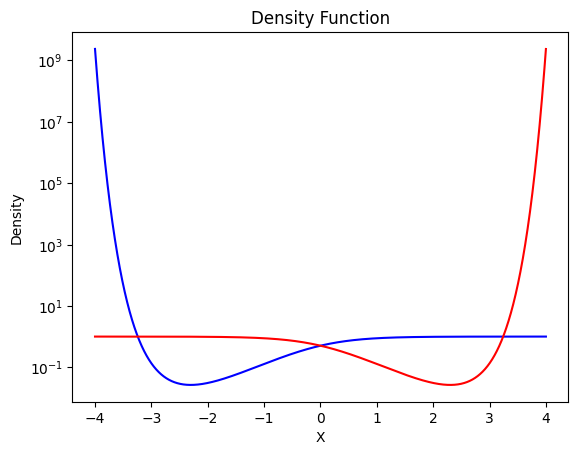

In [13]:
plt.plot(x, rho_1(x), 'b')
plt.plot(x, rho_2(x), 'r')
plt.yscale('log')
plt.title('Density Function')
plt.xlabel('X')
plt.ylabel('Density')

### Example 7 : Multiple Constant Classes

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import numpy as np


def compute_classificability_numerically_v2(x, raws, sample_points=10000, colors=None, force_balance=True, pdf_resolution=10000):
    # Compute classificability numerically (Optimal model is a simple threshold).
    domain = [np.min(x), np.max(x)]
    preds = []
    for i in range(5):
        # Train
        x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, sample_points, resolution=pdf_resolution, force_balance=True)
        x_data = x_data.reshape(-1,1)
        clf = RandomForestClassifier(max_depth=2, random_state=0)
        clf.fit(x_data, y_data)
        # Test
        x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, sample_points, resolution=pdf_resolution, force_balance=True)
        x_data = x_data.reshape(-1,1)
        preds.append( np.sum(clf.predict(x_data) == y_data) / len(y_data) )

    optimal_threshold, max_accuracy = 0.5, np.mean(preds)

    aux.print_numerical_classificability(max_accuracy)
    aux.data_plots(x_data, y_data, optimal_threshold, raws, domain, raws=None, colors=colors, bins=30)
    return max_accuracy


				####################################################################
							Classificability: 0.2501
				####################################################################



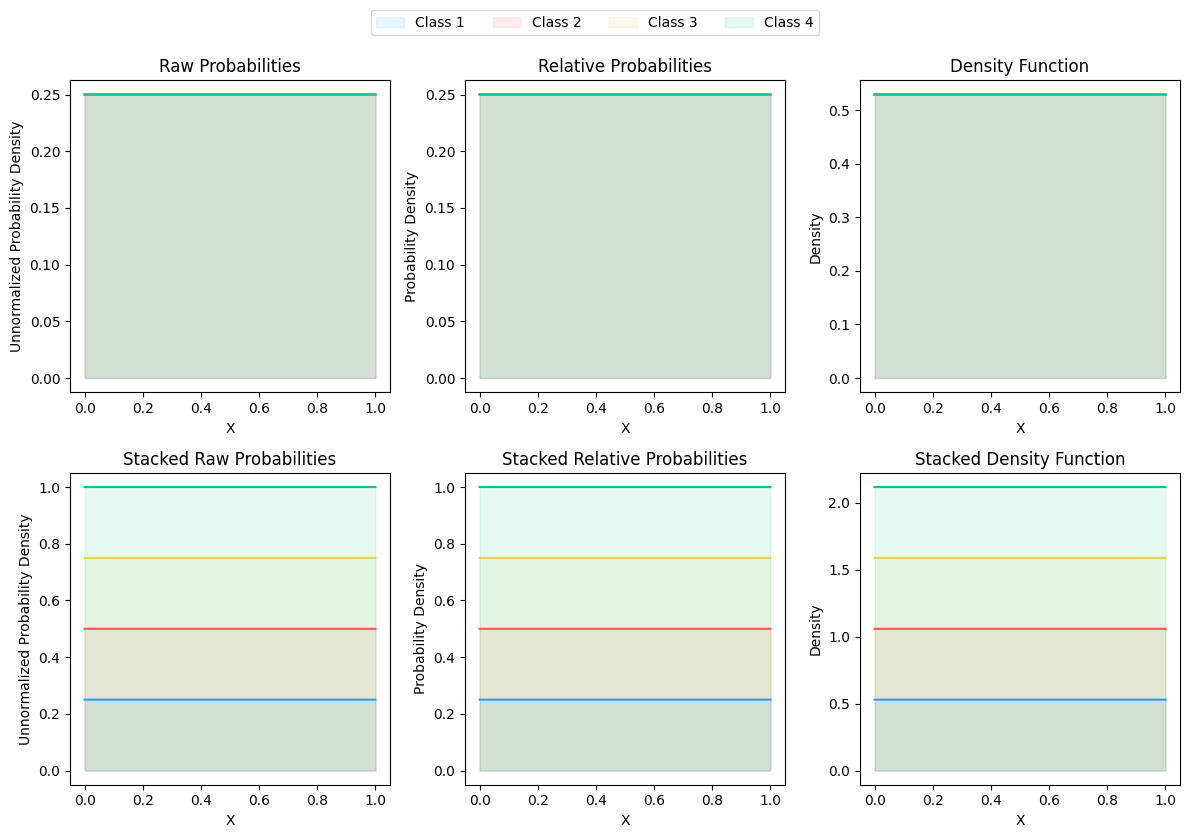


				####################################################################
						  Numerical Classificability: 0.2491
				####################################################################



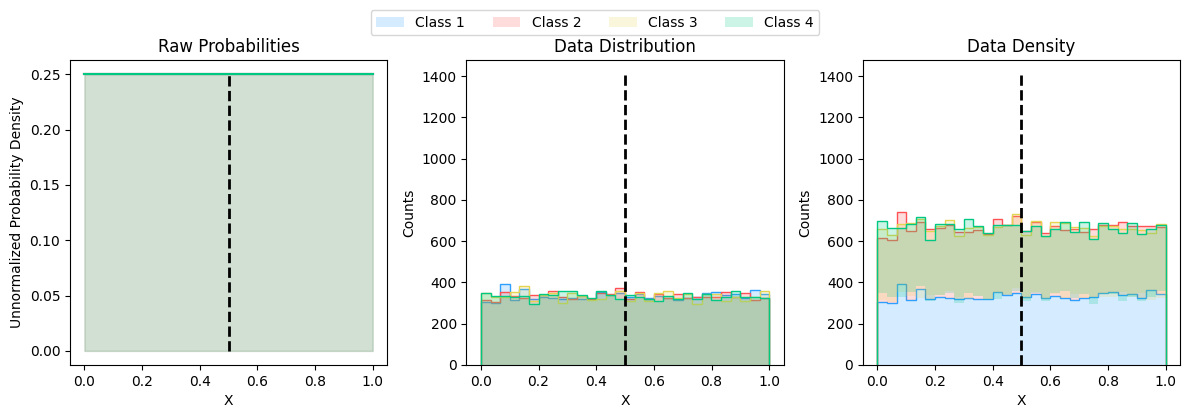


				####################################################################
					      Estimated Classificability: 0.2664 ± 0.0003
				####################################################################



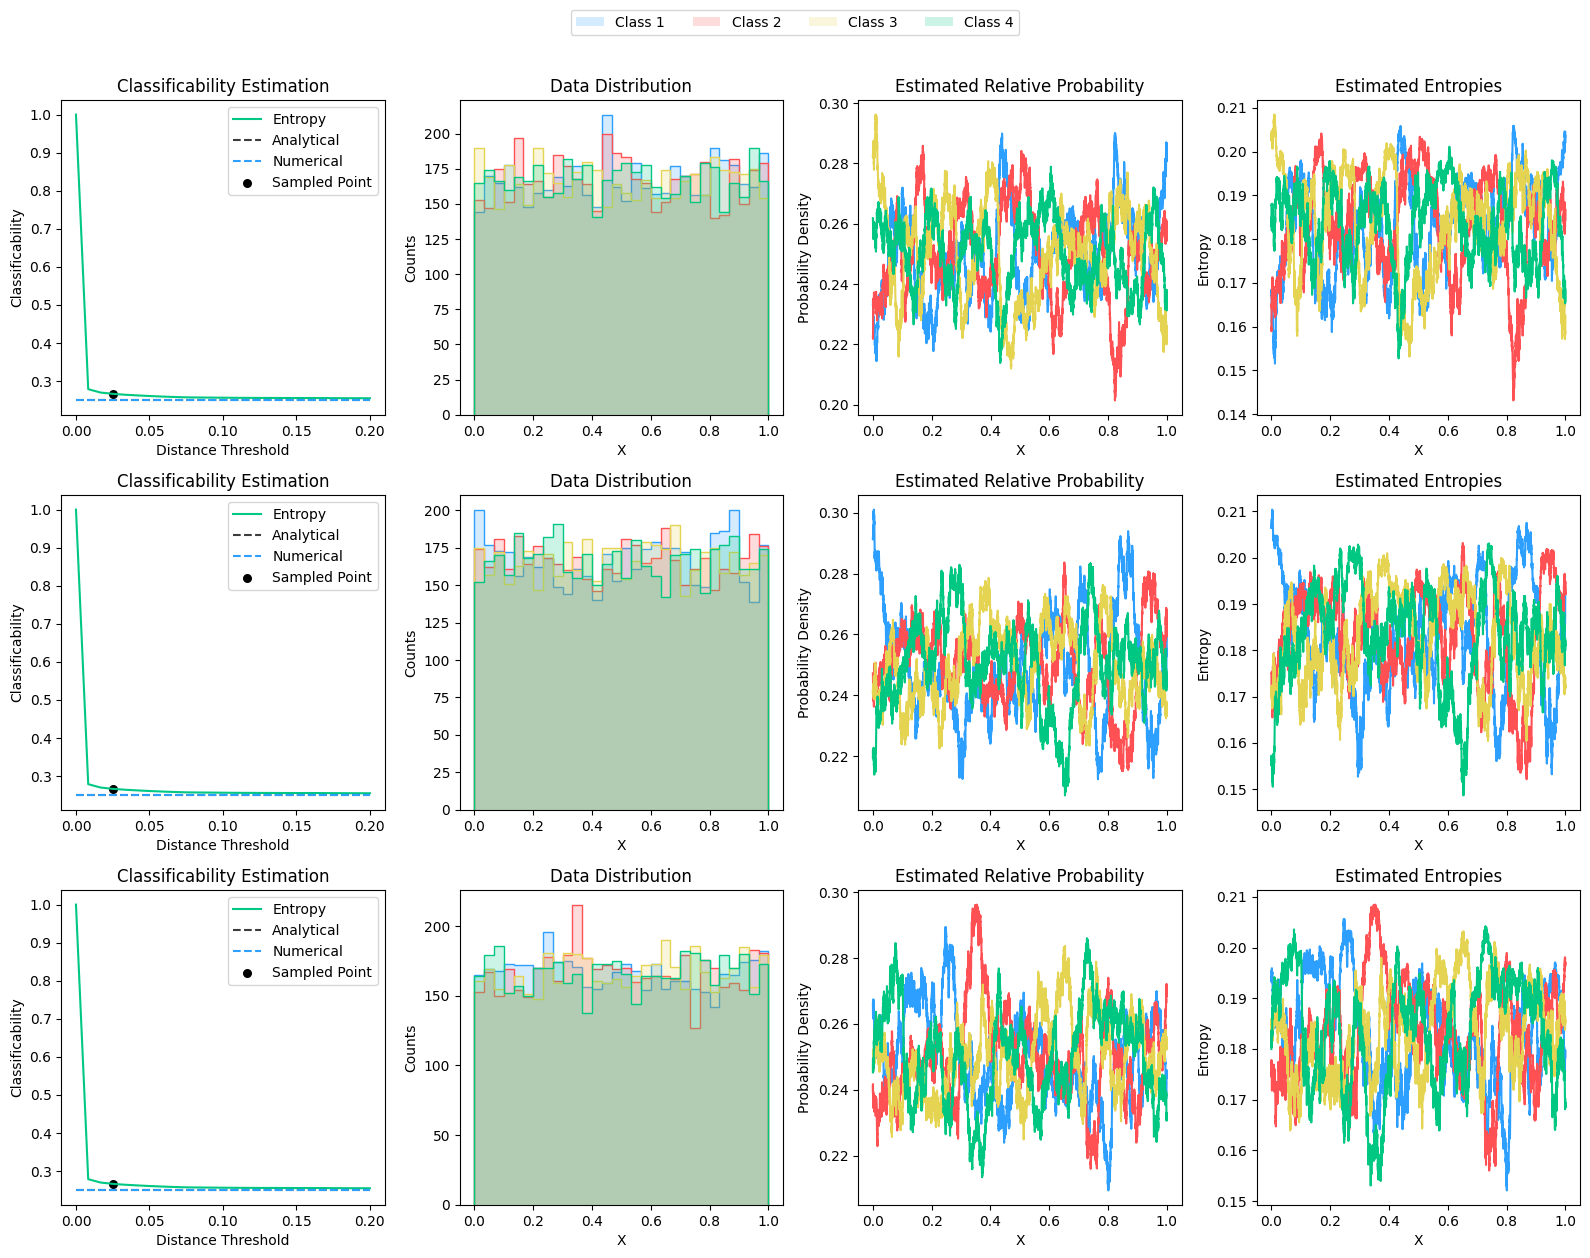

In [15]:
# Compute classificability analytically.
x = np.arange(0,1,0.0001)
raw_1 = lambda x : (1/4) * np.ones_like(x)
raw_2 = lambda x : (1/4) * np.ones_like(x)
raw_3 = lambda x : (1/4) * np.ones_like(x)
raw_4 = lambda x : (1/4) * np.ones_like(x)
raws = [raw_1, raw_2, raw_3, raw_4]

p_1 = lambda x : raw_1(x) / np.sum(np.stack([r(x) for r in raws]).T, axis=1)
p_2 = lambda x : raw_2(x) / np.sum(np.stack([r(x) for r in raws]).T, axis=1)
p_3 = lambda x : raw_3(x) / np.sum(np.stack([r(x) for r in raws]).T, axis=1)
p_4 = lambda x : raw_4(x) / np.sum(np.stack([r(x) for r in raws]).T, axis=1)
ps = [p_1, p_2, p_3, p_4]

rho_1 = lambda x : p_1(x) * np.exp(1 - np.min(np.stack([r(x) for r in ps]).T, axis=1))
rho_2 = lambda x : p_2(x) * np.exp(1 - np.min(np.stack([r(x) for r in ps]).T, axis=1))
rho_3 = lambda x : p_3(x) * np.exp(1 - np.min(np.stack([r(x) for r in ps]).T, axis=1))
rho_4 = lambda x : p_4(x) * np.exp(1 - np.min(np.stack([r(x) for r in ps]).T, axis=1))
rhos = [rho_1, rho_2, rho_3, rho_4]

colors =  ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']
force_balance = True

analytical_classificability = compute_classificability_analytically(x, raws, ps, rhos, colors=colors)
numerical_classificability = compute_classificability_numerically_v2(x, raws, sample_points=10000, colors=colors, force_balance=force_balance)
estimate_classificability_numerically(x, raws, analytical_classificability, numerical_classificability, estimation_measurement_threshold=0.025, sample_points=5000, colors=colors, force_balance=force_balance)